# Setup

In [14]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import os

In [15]:
import sys
sys.path.append("../")

from utils.seed_all import seed_all

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

In [16]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.2)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge


    plt.xticks(np.arange(0, img_loss.shape[1], 5))  # x-axis (Byte Index)
    plt.yticks(np.arange(0, img_loss.shape[0], 5))  # y-axis (Window Index)

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

In [17]:
def load_data(base_file):
    with open(f'{base_file}/config.yaml', "r") as f:
        config = yaml.safe_load(f)
    path = f'{base_file}/train_labels_predictions.pt'
    cache = torch.load(path, weights_only=False)
    y_true, y_out = cache['y_true'], cache['y_scores']
    y_pred, y_scores = y_out
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    y_true['scores'] = y_scores.mean(axis=(1, 2))

    return y_true, y_pred, y_scores, config

In [18]:
def get_window_metrics(base_path):
    windows = {}

    runs = [f for f in os.listdir(base_path)]
    for run in runs:
        run_path = f'{base_path}/{run}'
        print(run_path)

        if not os.path.exists(f'{run_path}/train_labels_predictions.pt'):
            continue

        try:
            with open(f'{run_path}/config.yaml', "r") as f:
                config = yaml.safe_load(f)
            path = f'{run_path}/train_labels_predictions.pt'
            cache = torch.load(path, weights_only=False)
            y_true, y_out = cache['y_true'], cache['y_scores']
            y_pred, y_scores = y_out
            y_pred = np.array(y_pred)
            y_scores = np.array(y_scores)
            y_true['scores'] = y_scores.mean(axis=(1, 2))

            y_true_benign = y_true[y_true["label"] == 'Normal']
            mean = y_true_benign["scores"].mean()
            std = y_true_benign["scores"].std()
            windows[config['pre_processing']['window_size']] = {'mean': mean, 'std': std}
        except:
            continue

    return windows

In [19]:
def density_function(y_true_benign, quantile=0.9999):
    threshold = y_true_benign["scores"].quantile(quantile)

    # Calculate mean and std
    mean = y_true_benign["scores"].mean()
    std = y_true_benign["scores"].std()

    # Plot histogram + KDE
    # y_true_benign["scores"].plot(kind="hist", bins=20, density=True, alpha=0.6, edgecolor="black")
    y_true_benign["scores"].plot(kind="kde")

    # Add mean line
    plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")

    # Add ±1 std lines
    plt.axvline(mean - std, color="blue", linestyle=":", linewidth=2, label=f"-1 Std = {mean-std:.2f}")
    plt.axvline(mean + std, color="blue", linestyle=":", linewidth=2, label=f"+1 Std = {mean+std:.2f}")
    plt.axvline(threshold, color="yellow", linestyle=":", linewidth=2, label=f"Quantile={quantile}")

    plt.xlabel("Scores")
    plt.title("Scores Distribution with Mean & Std")
    plt.legend()
    plt.show()

# Base config

In [20]:
y_true, y_pred, y_scores, config = load_data('../runs/base_config/L2_tcn_pred_TOWIDS_20250917_135238')
y_true_benign = y_true[y_true["label"] == 'Normal']

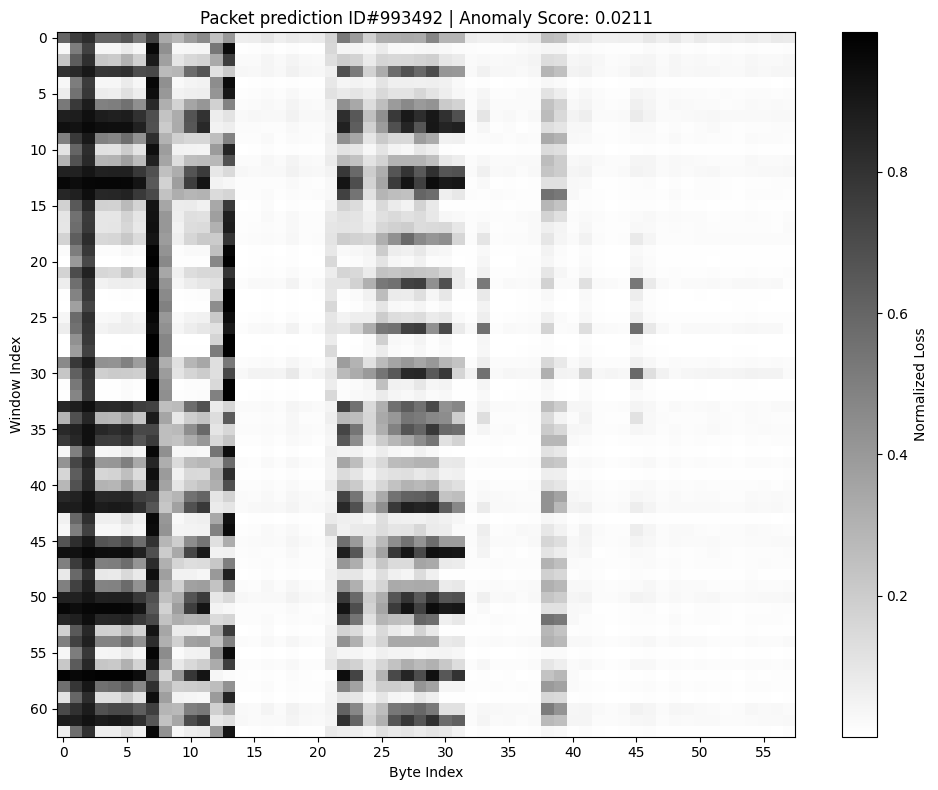

In [10]:
idx = y_true_benign.index[2]
plot_img_loss(y_pred[idx], name=f'Packet prediction ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

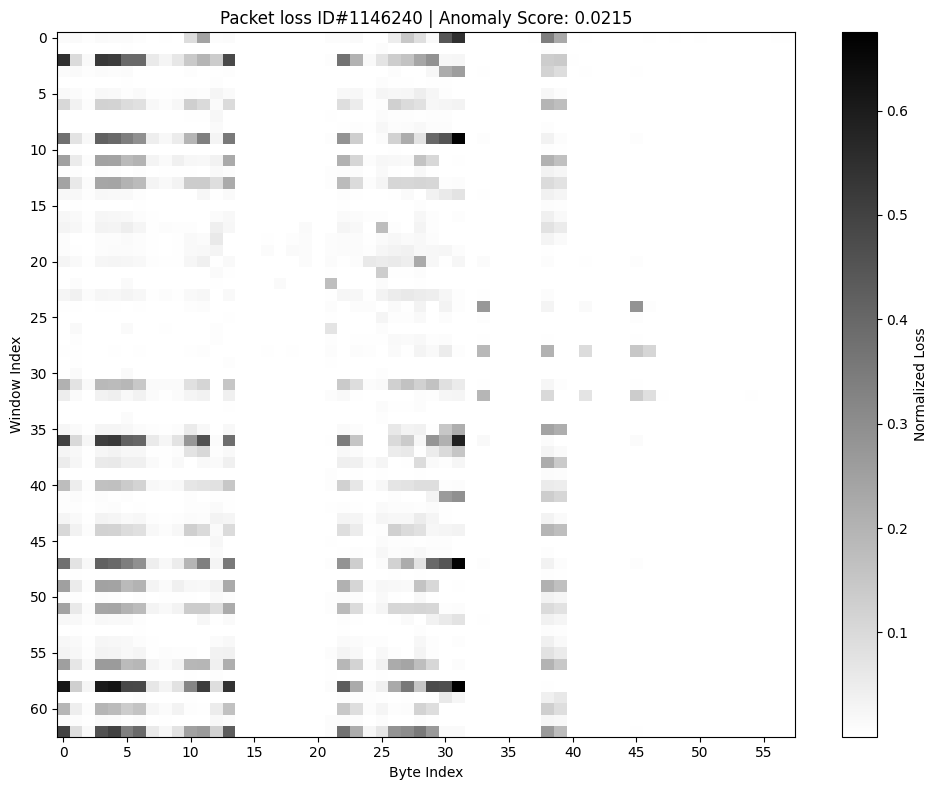

In [11]:
idx = y_true_benign.index[65]
plot_img_loss(y_scores[idx], name=f'Packet loss ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

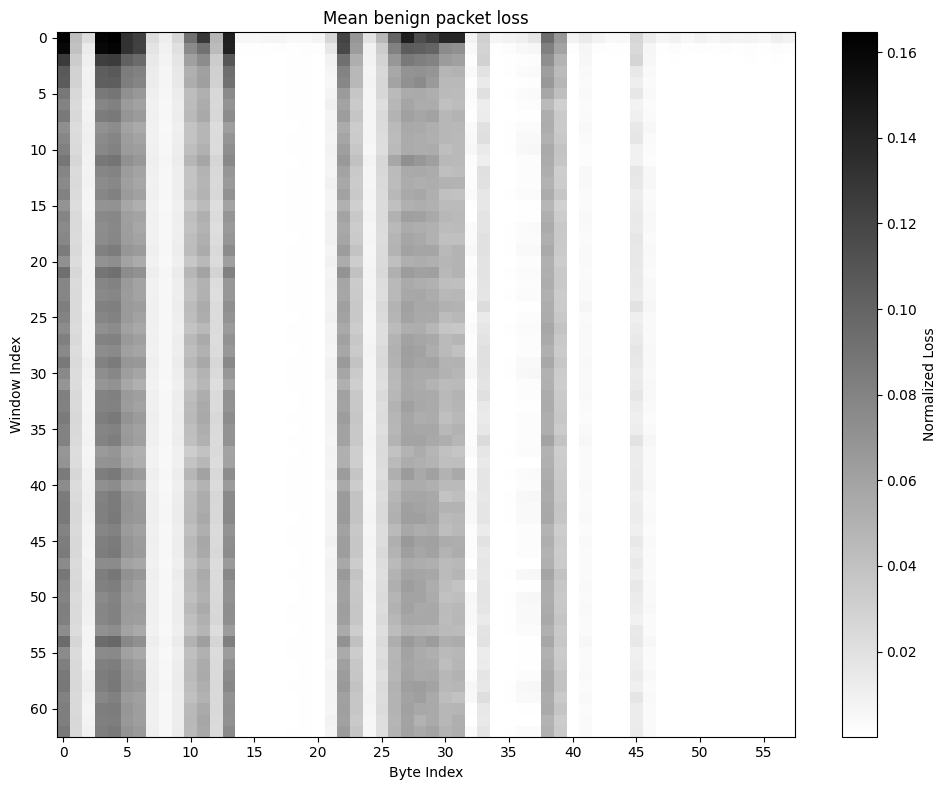

In [12]:
plot_img_loss(y_scores[y_true['label'] == 'Normal'].mean(0), name=f'Mean benign packet loss')

In [21]:
def get_threshold_table(y_true_benign):
    ts = [0.95, 0.98, 0.99, 0.999, 0.9999]
    r = {}
    for t in ts:
        threshold = y_true_benign["scores"].quantile(t)
        fp = y_true_benign[y_true_benign["scores"] > threshold]
        r[t] = {
            'count': len(fp),
            'mean': fp['scores'].mean(),
            'std': fp['scores'].std(),
            # 'fp': fp
        }
    return r

In [22]:
t_results = get_threshold_table(y_true_benign)

In [23]:
pd.DataFrame(t_results)

,0.9500,0.9800,0.9900,0.9990,0.9999
count,33.000000,14.000000,7.000000,1.000000,1.000000
mean,0.031662,0.032591,0.033227,0.033723,0.033723
std,0.000989,0.000719,0.000370,NaN,NaN


In [28]:
best_quantile = 0.95

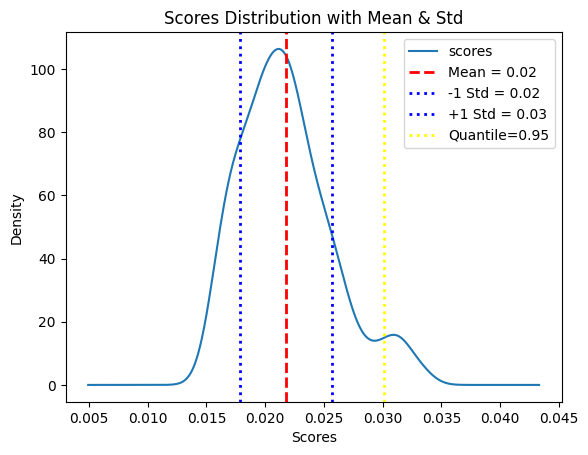

In [29]:
density_function(y_true_benign, quantile=best_quantile)

In [ ]:
threshold = y_true_benign["scores"].quantile(best_quantile)
fp = y_true_benign[y_true_benign["scores"] > threshold]

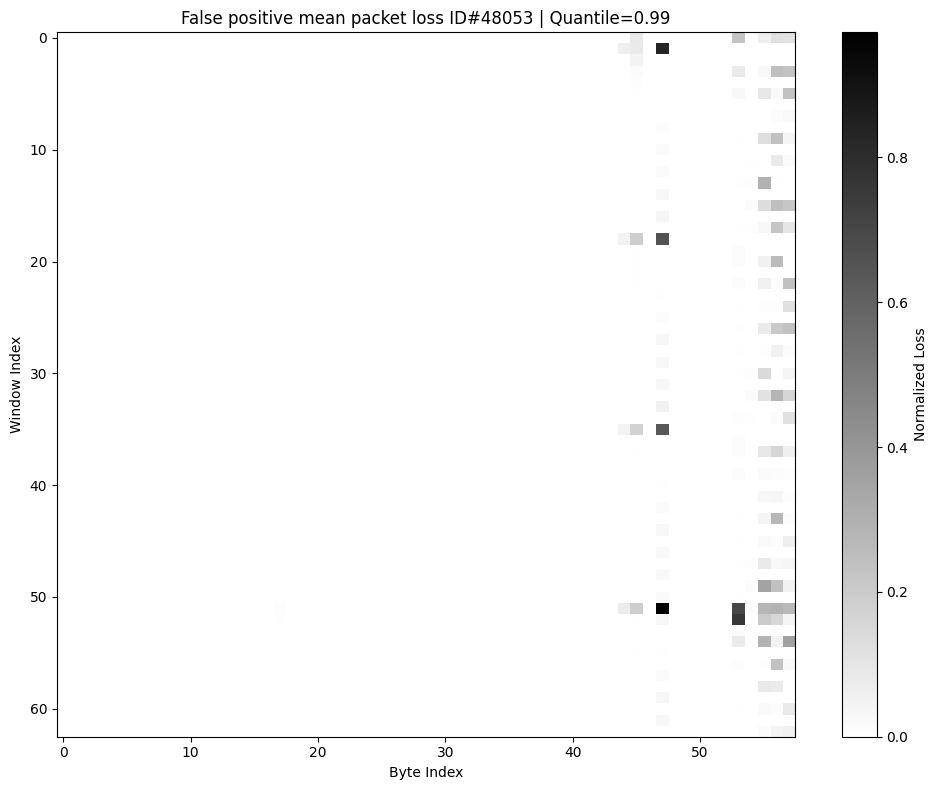

In [25]:
idx = fp.index[3]
plot_img_loss(y_scores[idx], name=f'False positive mean packet loss ID#{y_true['start_idx'].iloc[idx]} | Quantile={best_quantile}')

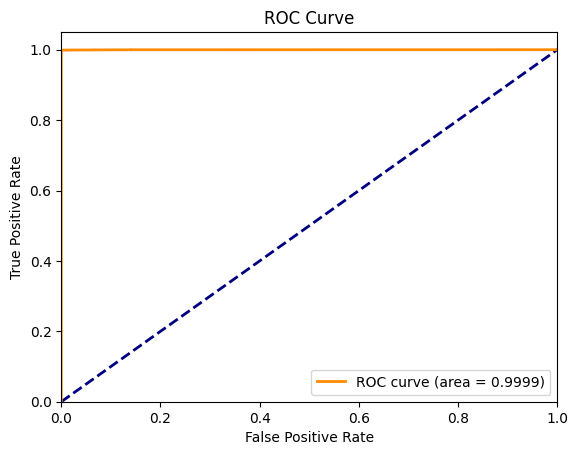

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_scores[:, 4:, :].mean((1, 2)))
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_scores[:, 4:, :].mean((1, 2)))
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()